# 电信客户流失预测 - 逻辑回归模型

## 项目简介
基于电信公司客户数据，构建逻辑回归模型识别影响客户流失的关键因素。

### 核心流程
- **数据准备**：加载、清洗、编码
- **特征工程**：VIF共线性检验，筛选特征
- **模型训练**：原模型（7特征）vs 重建模型（3特征）
- **模型评估**：AUC、召回率、精确率、F1
- **阈值优化**：寻找最佳决策阈值，四档风险分层

## 1. 环境准备

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_score, recall_score, ConfusionMatrixDisplay
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
pd.set_option('display.unicode.east_asian_width', True)

## 2. 数据加载与清洗

In [2]:
# 加载数据
df = pd.read_csv('customerchurn.csv')
print(f"原始数据: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f"\n缺失值:\n{df.isnull().sum()}")
print(f"\n重复行: {df.duplicated().sum()}")

# 去重
df = df.drop_duplicates().reset_index(drop=True)
print(f"去重后: {df.shape[0]} 行")

# 查看目标变量分布
print(f"\n流失率: {df['Churn'].mean():.2%}")
print(df['Churn'].value_counts())

原始数据: 7032 行 × 7 列

缺失值:
Churn              0
MonthlyCharges     0
SeniorCitizen      0
PaymentMethod      0
InternetService    0
tenure             0
Contract           0
dtype: int64

重复行: 177
去重后: 6855 行

流失率: 26.37%
Churn
0    5047
1    1808
Name: count, dtype: int64


## 3. 特征工程

In [3]:
# 编码分类变量（与model_service.py保持一致）
INTERNET_MAP = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
CONTRACT_MAP = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}

df['InternetService_enc'] = df['InternetService'].map(INTERNET_MAP)
df['Contract_enc'] = df['Contract'].map(CONTRACT_MAP)

# PaymentMethod哑变量（drop_first=True，基准类为Electronic check）
pay_dummies = pd.get_dummies(df['PaymentMethod'], prefix='Pay', drop_first=True)
df = pd.concat([df, pay_dummies], axis=1)

print("编码完成:")
print(f"  InternetService: {INTERNET_MAP}")
print(f"  Contract: {CONTRACT_MAP}")
print(f"  PaymentMethod哑变量: {list(pay_dummies.columns)}")

编码完成:
  InternetService: {'No': 0, 'DSL': 1, 'Fiber optic': 2}
  Contract: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
  PaymentMethod哑变量: ['Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check']


In [4]:
# VIF多重共线性检验
def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values.astype(float), i) 
                       for i in range(X.shape[1])]
    vif_data['Status'] = vif_data['VIF'].apply(
        lambda v: 'Normal' if v < 5 else ('Moderate' if v < 10 else 'Severe'))
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# 初始特征集
initial_features = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges',
    'InternetService_enc', 'Contract_enc',
    'Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check'
]

X_initial = df[initial_features].astype(float)
vif_result = compute_vif(X_initial)
print("初始特征VIF:")
print(vif_result.to_string(index=False))

# 删除高共线特征
print("\n决策: 删除 MonthlyCharges (VIF过高，与InternetService高度相关)")
final_features = [f for f in initial_features if f != 'MonthlyCharges']
print(f"最终特征 ({len(final_features)}个): {final_features}")

初始特征VIF:
             Feature       VIF   Status
      MonthlyCharges 39.435308   Severe
 InternetService_enc 28.328299   Severe
              tenure  6.438244 Moderate
        Contract_enc  3.910027   Normal
Pay_Electronic check  2.190020   Normal
     Pay_Credit card  1.636775   Normal
    Pay_Mailed check  1.341998   Normal
       SeniorCitizen  1.306223   Normal

决策: 删除 MonthlyCharges (VIF过高，与InternetService高度相关)
最终特征 (7个): ['SeniorCitizen', 'tenure', 'InternetService_enc', 'Contract_enc', 'Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check']


## 4. 原模型建模（7个特征）

In [5]:
# 定义原模型特征（与model_service.py对齐）
ORIGINAL_FEATURES = [
    'SeniorCitizen', 'tenure', 'InternetService_enc', 'Contract_enc',
    'Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check'
]

X_orig = df[ORIGINAL_FEATURES].astype(float)
y = df['Churn']

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_orig, y, test_size=0.3, random_state=42, stratify=y
)

# 构建Pipeline（标准化 + 逻辑回归）
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# 训练模型
pipe.fit(X_train, y_train)
y_prob = pipe.predict_proba(X_test)[:, 1]

print(f"原模型训练完成")
print(f"测试集AUC: {roc_auc_score(y_test, y_prob):.4f}")

原模型训练完成
测试集AUC: 0.8438


In [6]:
# 使用statsmodels进行统计推断（全样本）
scaler_temp = StandardScaler()
X_scaled = scaler_temp.fit_transform(X_orig)
X_sm = sm.add_constant(X_scaled)

logit_model = sm.Logit(y, X_sm)
result = logit_model.fit(disp=False)

# 提取统计量
stats_df = pd.DataFrame({
    'Feature': result.params.index,
    'Coef': result.params.values,
    'Std.Err': result.bse.values,
    'z': result.tvalues.values,
    'P>|z|': result.pvalues.values,
    'OR': np.exp(result.params.values),
    '95% CI Lower': np.exp(result.conf_int()[0]),
    '95% CI Upper': np.exp(result.conf_int()[1])
})

print("\n回归结果:")
print(stats_df.round(4).to_string(index=False))
print(f"\nMcFadden R²: {result.prsquared:.4f}")
print(f"AIC: {result.aic:.4f}, BIC: {result.bic:.4f}")


回归结果:
Feature    Coef  Std.Err        z  P>|z|     OR  95% CI Lower  95% CI Upper
  const -1.6093   0.0446 -36.0520 0.0000 0.2000        0.1833        0.2183
     x1  0.1289   0.0303   4.2526 0.0000 1.1376        1.0720        1.2072
     x2 -0.7479   0.0490 -15.2674 0.0000 0.4734        0.4300        0.5211
     x3  0.7782   0.0436  17.8590 0.0000 2.1775        1.9993        2.3717
     x4 -0.6208   0.0617 -10.0653 0.0000 0.5375        0.4763        0.6066
     x5 -0.0263   0.0464  -0.5677 0.5702 0.9740        0.8894        1.0667
     x6  0.1998   0.0439   4.5502 0.0000 1.2212        1.1205        1.3309
     x7 -0.0401   0.0468  -0.8576 0.3911 0.9607        0.8766        1.0529

McFadden R²: 0.2614
AIC: 5858.1744, BIC: 5912.8363


## 5. 原模型评估

In [7]:
# 默认阈值评估
DEFAULT_THRESHOLD = 0.35
y_pred_default = (y_prob >= DEFAULT_THRESHOLD).astype(int)

print(f"默认阈值 {DEFAULT_THRESHOLD} 下的表现:")
report = classification_report(y_test, y_pred_default, 
                               target_names=['未流失', '流失'], output_dict=True)
print(f"  Accuracy: {report['accuracy']:.4f}")
print(f"  流失类 - Precision: {report['流失']['precision']:.4f}, "
      f"Recall: {report['流失']['recall']:.4f}, F1: {report['流失']['f1-score']:.4f}")

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred_default)
tn, fp, fn, tp = cm.ravel()
print(f"\n混淆矩阵: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"TPR (Recall): {tp/(tp+fn):.4f}, FPR: {fp/(fp+tn):.4f}")

默认阈值 0.35 下的表现:
  Accuracy: 0.6578
  流失类 - Precision: 0.4302, Recall: 0.9134, F1: 0.5849

混淆矩阵: TN=857, FP=657, FN=47, TP=496
TPR (Recall): 0.9134, FPR: 0.4339


In [8]:
# 交叉验证
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics = {
    'AUC': cross_val_score(pipe, X_orig, y, cv=cv, scoring='roc_auc'),
    'Recall': cross_val_score(pipe, X_orig, y, cv=cv, scoring='recall'),
    'Precision': cross_val_score(pipe, X_orig, y, cv=cv, scoring='precision'),
    'F1': cross_val_score(pipe, X_orig, y, cv=cv, scoring='f1')
}

print("5折交叉验证结果:")
for metric, scores in cv_metrics.items():
    print(f"  {metric}: {scores.mean():.4f} ± {scores.std():.4f}")

5折交叉验证结果:
  AUC: 0.8349 ± 0.0127
  Recall: 0.8081 ± 0.0250
  Precision: 0.4991 ± 0.0158
  F1: 0.6170 ± 0.0184


## 6. 阈值优化与风险分层

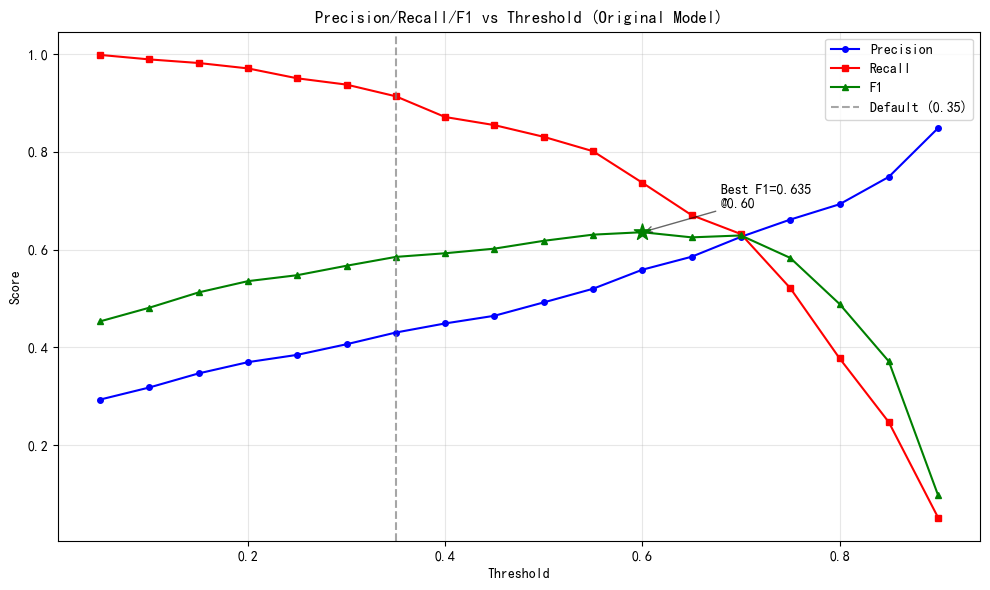

最佳F1阈值: 0.60
  Precision: 0.559
  Recall: 0.737
  F1: 0.635


In [9]:
# 扫描不同阈值下的指标
thresholds = np.arange(0.05, 0.95, 0.05)
metrics_list = []

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    metrics_list.append({'threshold': thresh, 'precision': p, 'recall': r, 'f1': f1})

metrics_df = pd.DataFrame(metrics_list)

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['threshold'], metrics_df['precision'], 'b-o', label='Precision', markersize=4)
plt.plot(metrics_df['threshold'], metrics_df['recall'], 'r-s', label='Recall', markersize=4)
plt.plot(metrics_df['threshold'], metrics_df['f1'], 'g-^', label='F1', markersize=4)
plt.axvline(x=DEFAULT_THRESHOLD, color='gray', linestyle='--', alpha=0.7, label=f'Default ({DEFAULT_THRESHOLD})')

# 标注最佳F1阈值
best_idx = metrics_df['f1'].idxmax()
best_thresh = metrics_df.loc[best_idx, 'threshold']
plt.scatter(best_thresh, metrics_df.loc[best_idx, 'f1'], s=150, c='green', zorder=5, marker='*')
plt.annotate(f'Best F1={metrics_df.loc[best_idx, "f1"]:.3f}\n@{best_thresh:.2f}',
             xy=(best_thresh, metrics_df.loc[best_idx, 'f1']),
             xytext=(best_thresh+0.08, metrics_df.loc[best_idx, 'f1']+0.05),
             arrowprops=dict(arrowstyle='->', color='black', alpha=0.6))

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision/Recall/F1 vs Threshold (Original Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"最佳F1阈值: {best_thresh:.2f}")
print(f"  Precision: {metrics_df.loc[best_idx, 'precision']:.3f}")
print(f"  Recall: {metrics_df.loc[best_idx, 'recall']:.3f}")
print(f"  F1: {metrics_df.loc[best_idx, 'f1']:.3f}")

In [10]:
# 四档风险分层（基于三个锚点）
RECALL_TARGET = 0.90
PRECISION_TARGET = 0.60

# 找到三个关键阈值
recall_90_idx = metrics_df[metrics_df['recall'] >= RECALL_TARGET]['threshold'].max()
precision_60_idx = metrics_df[metrics_df['precision'] >= PRECISION_TARGET]['threshold'].min()

# 排序得到分层边界
anchor_points = sorted([recall_90_idx, best_thresh, precision_60_idx])
low_cut, mid_cut, high_cut = anchor_points

print("四档风险分层:")
print(f"  低风险:     P < {low_cut:.2f}  (Recall≥{RECALL_TARGET:.0%}锚点)")
print(f"  中等风险:   {low_cut:.2f} ≤ P < {mid_cut:.2f}  (F1最优锚点)")
print(f"  较高风险:   {mid_cut:.2f} ≤ P < {high_cut:.2f}  (Precision≥{PRECISION_TARGET:.0%}锚点)")
print(f"  高风险:     P ≥ {high_cut:.2f}")

# 测试集分布
risk_levels = pd.cut(y_prob, bins=[-np.inf, low_cut, mid_cut, high_cut, np.inf],
                     labels=['低风险', '中等风险', '较高风险', '高风险'])
print(f"\n测试集风险分布:")
print(risk_levels.value_counts().sort_index())

四档风险分层:
  低风险:     P < 0.35  (Recall≥90%锚点)
  中等风险:   0.35 ≤ P < 0.60  (F1最优锚点)
  较高风险:   0.60 ≤ P < 0.70  (Precision≥60%锚点)
  高风险:     P ≥ 0.70

测试集风险分布:
低风险      904
中等风险    437
较高风险    168
高风险      548
Name: count, dtype: int64


## 7. 重建模型（3个核心特征）

In [11]:
# 重建模型特征（与model_service.py对齐）
REBUILT_FEATURES = ['tenure', 'InternetService_enc', 'Is_Electronic_check']

# 从原特征构造重建模型特征
X_rebuilt = pd.DataFrame({
    'tenure': df['tenure'].astype(float),
    'InternetService_enc': df['InternetService_enc'].astype(float),
    'Is_Electronic_check': (df['PaymentMethod'] == 'Electronic check').astype(float)
})

# 划分训练/测试集
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rebuilt, y, test_size=0.3, random_state=42, stratify=y
)

# 训练模型
pipe_r = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])
pipe_r.fit(X_train_r, y_train_r)
y_prob_r = pipe_r.predict_proba(X_test_r)[:, 1]

print(f"重建模型训练完成")
print(f"特征: {REBUILT_FEATURES}")
print(f"测试集AUC: {roc_auc_score(y_test_r, y_prob_r):.4f}")

重建模型训练完成
特征: ['tenure', 'InternetService_enc', 'Is_Electronic_check']
测试集AUC: 0.8345


In [12]:
# 重建模型评估
y_pred_r_default = (y_prob_r >= DEFAULT_THRESHOLD).astype(int)
report_r = classification_report(y_test_r, y_pred_r_default, 
                                 target_names=['未流失', '流失'], output_dict=True)

print(f"默认阈值 {DEFAULT_THRESHOLD} 下的表现:")
print(f"  Accuracy: {report_r['accuracy']:.4f}")
print(f"  流失类 - Precision: {report_r['流失']['precision']:.4f}, "
      f"Recall: {report_r['流失']['recall']:.4f}, F1: {report_r['流失']['f1-score']:.4f}")

# 交叉验证
cv_metrics_r = {
    'AUC': cross_val_score(pipe_r, X_rebuilt, y, cv=cv, scoring='roc_auc'),
    'Recall': cross_val_score(pipe_r, X_rebuilt, y, cv=cv, scoring='recall'),
    'Precision': cross_val_score(pipe_r, X_rebuilt, y, cv=cv, scoring='precision'),
    'F1': cross_val_score(pipe_r, X_rebuilt, y, cv=cv, scoring='f1')
}

print("\n5折交叉验证结果:")
for metric, scores in cv_metrics_r.items():
    print(f"  {metric}: {scores.mean():.4f} ± {scores.std():.4f}")

默认阈值 0.35 下的表现:
  Accuracy: 0.6544
  流失类 - Precision: 0.4255, Recall: 0.8840, F1: 0.5745

5折交叉验证结果:
  AUC: 0.8258 ± 0.0135
  Recall: 0.7683 ± 0.0246
  Precision: 0.5076 ± 0.0097
  F1: 0.6113 ± 0.0144


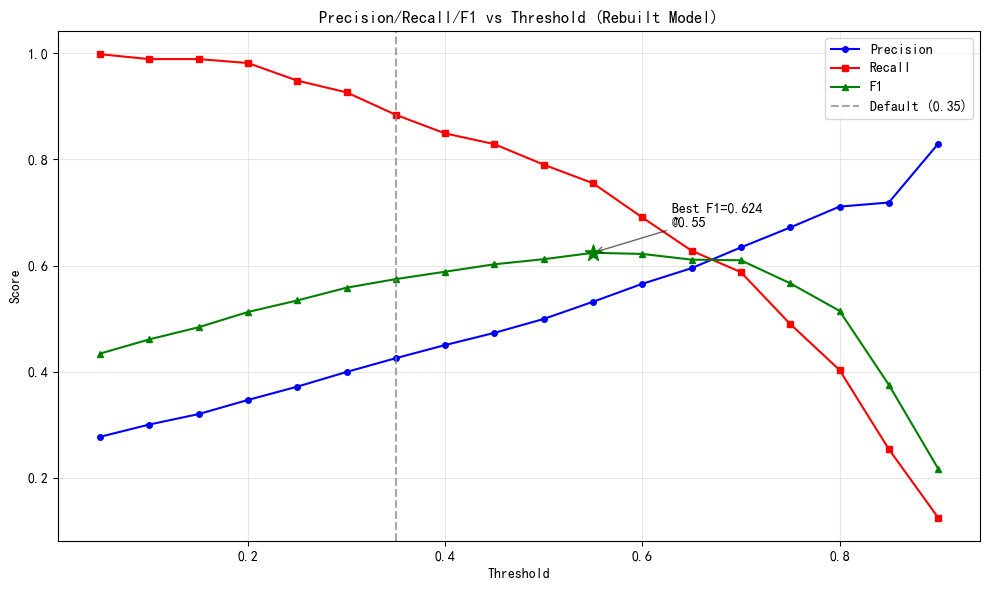

最佳F1阈值: 0.55
  Precision: 0.532
  Recall: 0.755
  F1: 0.624


In [13]:
# 重建模型阈值优化
metrics_list_r = []
for thresh in thresholds:
    y_pred = (y_prob_r >= thresh).astype(int)
    p = precision_score(y_test_r, y_pred, zero_division=0)
    r = recall_score(y_test_r, y_pred, zero_division=0)
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    metrics_list_r.append({'threshold': thresh, 'precision': p, 'recall': r, 'f1': f1})

metrics_df_r = pd.DataFrame(metrics_list_r)

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(metrics_df_r['threshold'], metrics_df_r['precision'], 'b-o', label='Precision', markersize=4)
plt.plot(metrics_df_r['threshold'], metrics_df_r['recall'], 'r-s', label='Recall', markersize=4)
plt.plot(metrics_df_r['threshold'], metrics_df_r['f1'], 'g-^', label='F1', markersize=4)
plt.axvline(x=DEFAULT_THRESHOLD, color='gray', linestyle='--', alpha=0.7, label=f'Default ({DEFAULT_THRESHOLD})')

best_idx_r = metrics_df_r['f1'].idxmax()
best_thresh_r = metrics_df_r.loc[best_idx_r, 'threshold']
plt.scatter(best_thresh_r, metrics_df_r.loc[best_idx_r, 'f1'], s=150, c='green', zorder=5, marker='*')
plt.annotate(f'Best F1={metrics_df_r.loc[best_idx_r, "f1"]:.3f}\n@{best_thresh_r:.2f}',
             xy=(best_thresh_r, metrics_df_r.loc[best_idx_r, 'f1']),
             xytext=(best_thresh_r+0.08, metrics_df_r.loc[best_idx_r, 'f1']+0.05),
             arrowprops=dict(arrowstyle='->', color='black', alpha=0.6))

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision/Recall/F1 vs Threshold (Rebuilt Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"最佳F1阈值: {best_thresh_r:.2f}")
print(f"  Precision: {metrics_df_r.loc[best_idx_r, 'precision']:.3f}")
print(f"  Recall: {metrics_df_r.loc[best_idx_r, 'recall']:.3f}")
print(f"  F1: {metrics_df_r.loc[best_idx_r, 'f1']:.3f}")

## 8. 模型对比与结论

In [14]:
# 汇总对比
comparison = pd.DataFrame({
    '指标': ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1'],
    '原模型(7特征)': [
        roc_auc_score(y_test, y_prob),
        report['accuracy'],
        report['流失']['precision'],
        report['流失']['recall'],
        report['流失']['f1-score']
    ],
    '重建模型(3特征)': [
        roc_auc_score(y_test_r, y_prob_r),
        report_r['accuracy'],
        report_r['流失']['precision'],
        report_r['流失']['recall'],
        report_r['流失']['f1-score']
    ]
})

print("模型对比 (默认阈值 0.35):")
print(comparison.to_string(index=False))

print(f"\n最佳阈值对比:")
print(f"  原模型: {best_thresh:.2f} (F1={metrics_df.loc[best_idx, 'f1']:.3f})")
print(f"  重建模型: {best_thresh_r:.2f} (F1={metrics_df_r.loc[best_idx_r, 'f1']:.3f})")

print(f"\n结论:")
print(f"  1. 原模型在AUC和F1上略优，但特征较多")
print(f"  2. 重建模型仅用3个特征，性能接近，更易部署和解释")
print(f"  3. 关键驱动因素: tenure(在网时长), InternetService(网络类型), PaymentMethod(支付方式)")
print(f"  4. 建议使用最佳阈值而非默认0.35，可提升F1约{(metrics_df.loc[best_idx, 'f1'] - report['流失']['f1-score']):.3f}")

模型对比 (默认阈值 0.35):
     指标  原模型(7特征)  重建模型(3特征)
      AUC       0.843831         0.834530
 Accuracy       0.657754         0.654351
Precision       0.430182         0.425532
   Recall       0.913444         0.883978
       F1       0.584906         0.574506

最佳阈值对比:
  原模型: 0.60 (F1=0.635)
  重建模型: 0.55 (F1=0.624)

结论:
  1. 原模型在AUC和F1上略优，但特征较多
  2. 重建模型仅用3个特征，性能接近，更易部署和解释
  3. 关键驱动因素: tenure(在网时长), InternetService(网络类型), PaymentMethod(支付方式)
  4. 建议使用最佳阈值而非默认0.35，可提升F1约0.051


## 9. 业务建议

In [15]:
print("""
业务建议:

1. 模型选择
   - 若追求最高准确率: 使用原模型（7特征）
   - 若注重部署简洁性: 使用重建模型（3特征），性能损失很小

2. 阈值策略
   - 不建议使用固定0.35阈值
   - 原模型推荐阈值: ~{:.2f} (平衡精确率和召回率)
   - 重建模型推荐阈值: ~{:.2f}

3. 风险分层运营
   - 高风险客户 (P≥{:.2f}): 立即干预，提供专属优惠
   - 较高风险 ({:.2f}≤P<{:.2f}): 主动联系，了解需求
   - 中等风险 ({:.2f}≤P<{:.2f}): 定期跟进，发送调查
   - 低风险 (P<{:.2f}): 常规维护

4. 关键洞察
   - 光纤用户流失风险更高
   - 电子支票支付客户更易流失
   - 在网时长越短，流失概率越大
   - 月付合约比年付合约风险高
""".format(
    best_thresh, best_thresh_r,
    high_cut, mid_cut, high_cut, low_cut, mid_cut, low_cut
))


业务建议:

1. 模型选择
   - 若追求最高准确率: 使用原模型（7特征）
   - 若注重部署简洁性: 使用重建模型（3特征），性能损失很小

2. 阈值策略
   - 不建议使用固定0.35阈值
   - 原模型推荐阈值: ~0.60 (平衡精确率和召回率)
   - 重建模型推荐阈值: ~0.55

3. 风险分层运营
   - 高风险客户 (P≥0.70): 立即干预，提供专属优惠
   - 较高风险 (0.60≤P<0.70): 主动联系，了解需求
   - 中等风险 (0.35≤P<0.60): 定期跟进，发送调查
   - 低风险 (P<0.35): 常规维护

4. 关键洞察
   - 光纤用户流失风险更高
   - 电子支票支付客户更易流失
   - 在网时长越短，流失概率越大
   - 月付合约比年付合约风险高

